<h3><center>Jets Astrofísicos</center><h3>


In [1]:
!pip install nbformat

In [2]:
import pymcel as pc
from pymcel import constantes as const 
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


Visualización del factor de Lorentz

Text(0.5, 1.0, 'Factor de Lorentz')

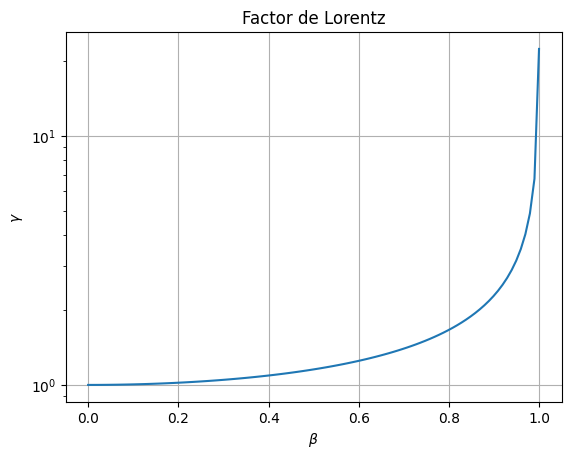

In [3]:
betas = np.linspace(0, 0.999, 100)
gammas = 1/np.sqrt(1-betas**2)

plt.semilogy(betas, gammas)
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\gamma$')
plt.grid()
plt.title('Factor de Lorentz')

Ecuación de movimiento:

 $$f^{\mu}=mA^{\mu}$$

 $$\Rightarrow$$

 $$\frac{d^2 x^{\mu}}{d \tau^2} = \frac{f^{\mu}}{m}$$



Cuadrifuerza de Faraday

$$f^{\mu} = \frac{q}{c} U_{\nu} F^{\mu \nu}$$

## Unidades

Las unidades en Electromagnetismo (EM) son las unidades gaussianas, unidades electromagneticas absolutas, se las inventaron en el siglo XIX y era muy dificil, siempre se usaba un objeto, p.e un imán. Gauss inventó la idea de que las unidades fueran absolutas en cualquier lugar dek universo.

$$F = \frac{q_1 q_2}{4\pi \epsilon_0 r^2}$$

inventemos unas unidades en las cuales:

$$F = \frac{q_1 q_2}{r^2}$$

Cuáles son las unidades de $q_1$:

$$|q| = \sqrt{|F|}  |r| $$

Si escojo un sistema de unidades $U_L, U_T, U_M, U_F, U_Q$, etc. puedo escribir la carga en el nuevo sistema de unidades asi: $q=q' U_Q$. Si usamos esto para escribir la fuerza:

$$F' U_F = \frac{q'_1 U_Q q'_2 U_Q}{4\pi \epsilon_0 r'^2 U_L}$$

Si usamos el hecho de que $F' = \frac{q'_1 q'_2}{r'^2}$

$$U_F = \frac{U_Q U_Q}{4\pi \epsilon_0 U_L^2}$$

Las unidades de carga en este sistema serán:

$$U_Q = U_L \sqrt{U_F 4\pi \epsilon_0}$$

In [4]:
eps0 = const.eps0
UL = 100e3  #100km
UM = const.m_e

# Unidades relativistas implica c=1, que implica c = UL / UT
UT = UL / const.c

# Unidades derivadas
UV = UL / UT
UA = UL / (UT**2)
UF = UM * UA

# Unidades gaussianas
UQ = UL * np.sqrt(UF * 4 * np.pi * eps0)
UE = UF / UQ
UB = UE / UV

C = 1


## Tensor de Faraday

In [5]:
def tensor_faraday_campo_uniforme(B0):
    Ex = Ey = Ez = 0
    Bx = By = 0
    Bz = B0
    F = np.array([
        [0, -Ex, -Ey, -Ez],
        [Ex, 0, -Bz, By],
        [Ey, Bz, 0, -Bx],
        [Ez, -By, Bx, 0]
    ])
    return F

In [6]:
tensor_faraday_campo_uniforme(1)

array([[ 0,  0,  0,  0],
       [ 0,  0, -1,  0],
       [ 0,  1,  0,  0],
       [ 0,  0,  0,  0]])

## Ecuación de movimiento de una carga

In [7]:
def edm_relativista(tau, Ys, m, q, B0):
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    dx0dtau = U0
    dx1dtau = U1
    dx2dtau = U2
    dx3dtau = U3

    F = tensor_faraday_campo_uniforme(B0)
    # U_mu = g_mu_nu * U^mu = diagonal([1, -1, -1, -1]) * U^mu 
    Usub = np.array([U0, -U1, -U2, -U3])

    #f0 = q/C * (Usub0 * F(0, 0) + Usub1 * F(0, 1) + Usub2 * F(0, 2) + Usub3 * F(0, 3))
    f = q/C * F @ Usub

    dU0dtau = f[0]/m
    dU1dtau = f[1]/m
    dU2dtau = f[2]/m
    dU3dtau = f[3]/m

    return np.array([dx0dtau, dx1dtau, dx2dtau, dx3dtau,
                      dU0dtau, dU1dtau, dU2dtau, dU3dtau])

In [8]:
edm_relativista(0, [0, 0, 0, 0, 0, 1, 1, 1], 1, 1, 1)

array([ 0.,  1.,  1.,  1.,  0.,  1., -1.,  0.])

In [9]:
edm_relativista(0, [0, 0, 0, 0, 1, 1, 1, 1], 1, 1, 1)

array([ 1.,  1.,  1.,  1.,  0.,  1., -1.,  0.])

## Condiciones iniciales

In [10]:
# En coordenadas temporales y espaciales
t0 = 0
r0 = np.array([1.0, 0.0, 0.0])
v0 = np.array([0.0, 0.5, 0.2])

# En coordenadas espacio-temporales
x0 = np.array([C*t0, r0[0], r0[1], r0[2]])
gamma0 = 1 / np.sqrt(1 - np.linalg.norm(v0)**2 / C**2)
U0 = np.array([gamma0, gamma0*v0[0], gamma0*v0[1], gamma0*v0[2]])

# Condiciones iniciales ahora si
Ys0 = np.concatenate((x0, U0))

## Integración

In [11]:
from scipy.integrate import solve_ivp

m = 1
q = 1
B0 = 1

taus = np.linspace(0, 10, 1000)

solucion = solve_ivp(
    edm_relativista,
    (taus[0], taus[-1]),
    Ys0,
    t_eval=taus,
    args=(m, q, B0),
    method='Radau'
)

In [12]:
solucion

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.001e-02 ...  9.990e+00  1.000e+01]
        y: [[ 0.000e+00  1.188e-02 ...  1.186e+01  1.187e+01]
            [ 1.000e+00  1.000e+00 ...  2.094e+00  2.091e+00]
            ...
            [ 5.934e-01  5.934e-01 ... -5.010e-01 -4.978e-01]
            [ 2.374e-01  2.374e-01 ...  2.374e-01  2.374e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 141
     njev: 2
      nlu: 10

Debido a que la solucion está en el espacio-tiempo, tenemos que recuperar las coordenadas espaciales y temporales

In [13]:
ts = solucion.y[0] / C
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]

In [14]:
fig = go.Figure(data=[go.Scatter3d(x=xs, y=ys, z=zs, mode='lines')])
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.show()

## Campo magnético helicoidal

$$
B_r = 0 \\
B_z = B_0 \\
B_\phi = \frac{B_z}{r}
$$

Convertirlo a cartesianas:

$$
B_x = B_r \cos\phi - B\phi \sin\phi \\
B_y = B_r \sin\phi + B\phi \cos\phi \\
B_z = B_z
$$

In [19]:
def tensor_faraday_campo_helicoidal(B0, B1, x, y, z):
    Ex = Ey = Ez = 0
    Bx = By = 0
    
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)

    Bx = -B1/r * np.sin(phi)
    By = B1/r* np.cos(phi)
    Bz = B0
    F = np.array([
        [0, -Ex, -Ey, -Ez],
        [Ex, 0, -Bz, By],
        [Ey, Bz, 0, -Bx],
        [Ez, -By, Bx, 0]
    ])
    return F


def edm_relativista(tau, Ys, m, q, B0, B1):
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    dx0dtau = U0
    dx1dtau = U1
    dx2dtau = U2
    dx3dtau = U3

    F = tensor_faraday_campo_helicoidal(B0, B1, x1, x2, x3)
    # U_mu = g_mu_nu * U^mu = diagonal([1, -1, -1, -1]) * U^mu 
    Usub = np.array([U0, -U1, -U2, -U3])

    #f0 = q/C * (Usub0 * F(0, 0) + Usub1 * F(0, 1) + Usub2 * F(0, 2) + Usub3 * F(0, 3))
    f = q/C * F @ Usub

    dU0dtau = f[0]/m
    dU1dtau = f[1]/m
    dU2dtau = f[2]/m
    dU3dtau = f[3]/m

    return np.array([dx0dtau, dx1dtau, dx2dtau, dx3dtau,
                      dU0dtau, dU1dtau, dU2dtau, dU3dtau])


# En coordenadas temporales y espaciales
t0 = 0
r0 = np.array([1.0, 0.0, 0.0])
v0 = np.array([0.0, 0.5, 0.2])

# En coordenadas espacio-temporales
x0 = np.array([C*t0, r0[0], r0[1], r0[2]])
gamma0 = 1 / np.sqrt(1 - np.linalg.norm(v0)**2 / C**2)
U0 = np.array([gamma0, gamma0*v0[0], gamma0*v0[1], gamma0*v0[2]])

# Condiciones iniciales ahora si
Ys0 = np.concatenate((x0, U0))

    

m = 1
q = 1
B0 = 1
B1 = 1

taus = np.linspace(0, 1000, 1000)

solucion = solve_ivp(
    edm_relativista,
    (taus[0], taus[-1]),
    Ys0,
    t_eval=taus,
    args=(m, q, B0, B1),
    method='Radau'
)

c:\Users\Equipo Hogar\Desktop\Relatividad General\Clase-Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
c:\Users\Equipo Hogar\Desktop\Relatividad General\Clase-Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
c:\Users\Equipo Hogar\Desktop\Relatividad General\Clase-Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
c:\Users\Equipo Hogar\Desktop\Relatividad General\Clase-Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [20]:
t0 = solucion.y[0] / C
xs = solucion.y[1] 
ys = solucion.y[2]
zs = solucion.y[3]

fig = go.Figure(data=[go.Scatter3d(x=xs, y=ys, z=zs, mode='lines')])
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.show()